In [2]:
%load_ext autoreload

%autoreload 2

In [3]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from pathlib import Path
from Preproces_prod import *


In [5]:
path_actual = Path.cwd()
path_data = path_actual.parent.parent / 'Efectividad_Nirse' / 'Data'
df = pd.read_csv(path_data/"ENTREGA2_ISCI_29_07_2024.CSV", encoding = "latin-1", sep = ";")
df.head()

,RUN,EDAD_M,FECHA_NAC,PESO,SEMANAS,SEXO,NACIONALIDAD_MADRE,PAIS_ORIGEN_MADRE,INS_C_M,INS_N_M,...,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,FECHA_DEF,CAUSA_DEF
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,17,01-10-2023,2865.0,38.0,1,C,NaN,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,18,02-10-2023,2790.0,38.0,1,C,NaN,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc84...,16,01-10-2023,1815.0,34.0,2,C,NaN,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,16,01-10-2023,2300.0,34.0,2,C,NaN,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874...,15,04-10-2023,3450.0,39.0,2,C,NaN,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def convertir_a_fecha(numero):
    if pd.isna(numero):
        return None 
    numero_str = str(int(numero))
    return datetime.strptime(numero_str, "%Y%m%d")

df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NAC'], format='%d-%m-%Y')
df['FECHA_ING'] = df['FECHA_ING'].apply(convertir_a_fecha)
df['FECHA_EGR'] = df['FECHA_EGR'].apply(convertir_a_fecha)
df['FECHA_INMUNIZACION'] = pd.to_datetime(df['FECHA_INMUNIZACION'], format='%d-%m-%Y')

In [4]:
areasUPC = [406, 412, 415, 405, 411, 414]
diagnosticosVRS = ['J121', 'J205', 'J210','J219', 'B974' ]

In [5]:
df['VRS'] = np.where(df[['DIAG1'#,'DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11'
                         ]].isin(diagnosticosVRS).any(axis=1), 1, 0)
df['event'] = df['VRS'].astype(bool)
df['group'] = np.where(df['FECHA_NAC']< pd.to_datetime("2024-04-01"), "CATCH_UP", "SEASONAL")

In [6]:
regiones = {
'Metropolitana de Santiago': 'METROPOLITANA',
'De Los Lagos': 'LOS LAGOS',
'De Valparaíso': 'VALPARAISO',
'Extranjero': 'EXTRANJERO',
'De Tarapacá': 'TARAPACA',
'Del Maule': 'MAULE',
'De Ñuble': 'NUBLE',
'Del Bíobío': 'BIOBIO',
"Del Libertador B. O'Higgins": "O'HIGGINS",
'De La Araucanía': 'ARAUCANIA',
'De Aisén del Gral. C. Ibáñez del Campo': 'AISEN',
'De Coquimbo': 'COQUIMBO',
'De Arica y Parinacota': 'ARICA Y PARINACOTA',
'De Antofagasta': 'ANTOFAGASTA',
'De Magallanes y de La Antártica Chilena': 'MAGALLANES Y ANTARTICA',
'De Los Ríos': 'LOS RIOS',
'Ignorada' : None,
'De Atacama': 'ATACAMA'
}

sex = {2:'Female',1:'Male',9:'intersex'}

comunas = pd.read_excel(path_data/"comunas.xlsx")
comunas = comunas.rename(columns = {'C_COM': 'COMUNA_N','NOM_REG':'NOMBRE_REGION'})
comunas = comunas.drop_duplicates(subset='COMUNA_N')

diagnosticos_upc = [406, 412, 415, 405, 411, 414]

cols_diagnostico = ['AREA_FUNC_I','AREAF_1_TRAS', 'AREAF_2_TRAS', 'AREAF_3_TRAS', 'AREAF_4_TRAS', 'AREAF_5_TRAS', 'AREAF_6_TRAS', 'AREAF_7_TRAS', 'AREAF_8_TRAS', 'AREAF_9_TRAS','AREAF_EGR']


for i in range(1, 10):
    year_col = f'ANO_{i}_TRAS'
    month_col = f'MES_{i}_TRAS'
    day_col = f'DIA_{i}_TRAS'
    date_col = f'fecha_tras_{i}'

    df[date_col] = pd.to_datetime({'year': df[year_col], 'month': df[month_col], 'day': df[day_col]}, format='%Y-%m-%d')


In [7]:
for col in cols_diagnostico:
    df[col] = df[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)


df['cama'] = np.where(df[cols_diagnostico].eq(1).any(axis=1),'UPC', "")

# graficos

In [ ]:
L=[]
df['days_upc'] = 0
df['dias_en_ing'] = (df['fecha_tras_1'] - df['FECHA_ING']).apply(lambda x: 1 + x.days if pd.notna(x) else None)
L.append('dias_en_ing')
for i in range(1, 10):
    date_col = f'fecha_tras_{i}'
    date_col_next = f'fecha_tras_{i+1}'
    diff = f'dias_en_area_{i}'
    L.append(diff)
    if i==9:
        date_col_next = 'FECHA_EGR'
    df[diff] = (df[date_col_next] - df[date_col]).apply(lambda x: 1 + x.days if pd.notna(x) else None)
    

df['days_upc'] += df['dias_en_ing'].fillna(0)*df['AREA_FUNC_I']

for i in range(1, 10):
    area_col = f'AREAF_{i}_TRAS'
    diff = f'dias_en_area_{i}'
    df['days_upc'] += df[diff].fillna(0)*df[area_col]

L.append('days_upc')
df[L][df['fecha_tras_1'].notna()]

In [9]:
df['days_upc_vrs'] = np.where((df['VRS']==1) & (df['days_upc']>0), df['days_upc'], 0)
df['days_estad_vrs'] = np.where((df['VRS']==1) & (df['DIAS_ESTAD']>0), df['DIAS_ESTAD'], 0) 

In [17]:
df_pf = pre_filtred('NAC_RNI_EGRESOS_ENTREGA_ISCI_16_09_2024_encr.csv',nirse=True)
df2 = filtros_IH(df_pf,nirse=True)

151149
post merge comunas 151149
post merge rural 151149
Datos perdidos por filtro peso:  924
Datos perdidos por filtro semanas y peso:  1441
Datos perdidos por fecha ingreso menor a fecha nacimiento: 0
Datos perdidos por edad madre atípica: 230


In [ ]:
peso_critic = 300 #exclusive (no se incluyen los de 500gr en la nueva data)
semana_lower = 22 #inclusive
semana_upper = 42 #inclusive


descart1 = df[df['PESO']<=peso_critic].shape[0]
descart2 = df[df['SEMANAS']<semana_lower].shape[0]
descart3 = df[df['SEMANAS']>semana_upper].shape[0]
descart4 = df[(df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna())].shape[0]

descart_tot = df[ (df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna())) ].shape[0]
descart_tot_vrs = df[ ((df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna()))) & (df['VRS']==1) ].shape[0]

df1 = df[(df['PESO']>peso_critic) & (df['SEMANAS']>=semana_lower) & (df['SEMANAS']<=semana_upper)]

df_eliminar = df1[(df1.SEMANAS >= 35 ) & (df1.PESO <=500)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]
print('Cantidad de datos con peso <=500 y semanas >=35: ', len(df1[(df.SEMANAS >= 35 ) & (df.PESO <=500)]) , '\n')

print('Cantidad de datos con peso >=6000: ', len( df[(df.PESO >= 6000 )]) , '\n')
df_eliminar= df1[(df1.PESO>=1000) & ( df1.SEMANAS <=25)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]

df1.loc[(df1['FECHA_INMUNIZACION'] >= df1['FECHA_ING']) & (df1.event ==1 ), 'FECHA_INMUNIZACION'] = pd.NaT
df1.loc[((df1['FECHA_ING'] - df1['FECHA_INMUNIZACION']).dt.days <= 7) & (df1['event']) & (~df1.FECHA_INMUNIZACION.isna()), 'FECHA_INMUNIZACION'] = pd.NaT

df1_outIngNac = df1[(df1['FECHA_ING'] <= df1['FECHA_NAC']) & (~df1['FECHA_ING'].isna())] 
df_filtrado=df1[~df1.RUN.isin(df1_outIngNac.RUN)]

print("Recibieron nirse : ", df_filtrado['FECHA_INMUNIZACION'].notna().sum())
df_filtrado['inmunizado'] = 1 - df_filtrado['FECHA_INMUNIZACION'].isna()

vrs = df_filtrado[df_filtrado.VRS == 1].drop_duplicates(subset=['RUN'], keep='first')
df_novrs = df_filtrado[~df_filtrado.RUN.isin(vrs.RUN.unique())].drop_duplicates(subset=['RUN'], keep='first')
df_filtrado = pd.concat([df_novrs,vrs])

df2=df_filtrado.copy()




In [29]:
df2 = df2[df2['days_estad_vrs'] > 0]
df_prop = df2.groupby(['inmunizado', 'days_estad_vrs'], as_index=False).size()
n_inmunizado = df_prop[df_prop['inmunizado'] == 1]['size'].sum()
n_no_inmunizado = df_prop[df_prop['inmunizado'] == 0]['size'].sum()
df_prop['prop'] = np.where(df_prop['inmunizado'], df_prop['size'] / n_inmunizado, df_prop['size'] / n_no_inmunizado)
full_range = pd.MultiIndex.from_product([[0, 1], range(1, int(df_prop['days_estad_vrs'].max() + 1))], names=['inmunizado', 'days_estad_vrs'])
df_full = df_prop.set_index(['inmunizado', 'days_estad_vrs']).reindex(full_range, fill_value=0).reset_index()

In [ ]:
df_full

## Data droping

In [32]:
columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado']
df_save = df2[columns]
df_save.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)

In [33]:
df_save

,RUN,days_estad_vrs,days_upc_vrs,inmunizado
145,68273352fd605f54261cc4e327ac14ba30fbb6a88badf0...,4.0,0.0,0
192,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,5.0,0.0,0
287,20c61c90172d3bd50cc3b31cd8d3b1ec5e6b4e8cacde0d...,3.0,0.0,1
336,9ab8dfceb64e0dccc88dda7866a4d299278cfcdaf1031a...,3.0,0.0,1
710,1cf7a2e04d23ca607b88a59efc4deafd9ca0764a92a6c0...,2.0,0.0,1
...,...,...,...,...
129530,36864e97e22c228f0b0dc445c66699ac02281e9da2ba96...,2.0,0.0,1
129656,912e3c37e4c76ebc482a480b23e40d31742faabce9790d...,2.0,0.0,1
130628,a838b37f51742bf39138aa218463fe015a3fd7178ac4c3...,1.0,0.0,1
131436,93c491735b5cc89d164317a01a70d9b5fb8d2722f76bc8...,7.0,0.0,1


## Días UPC

### histograma

In [6]:
df=df_save.copy()
#df = pd.read_csv(path_data/"graficos_felipe_nirse.csv")

22.0


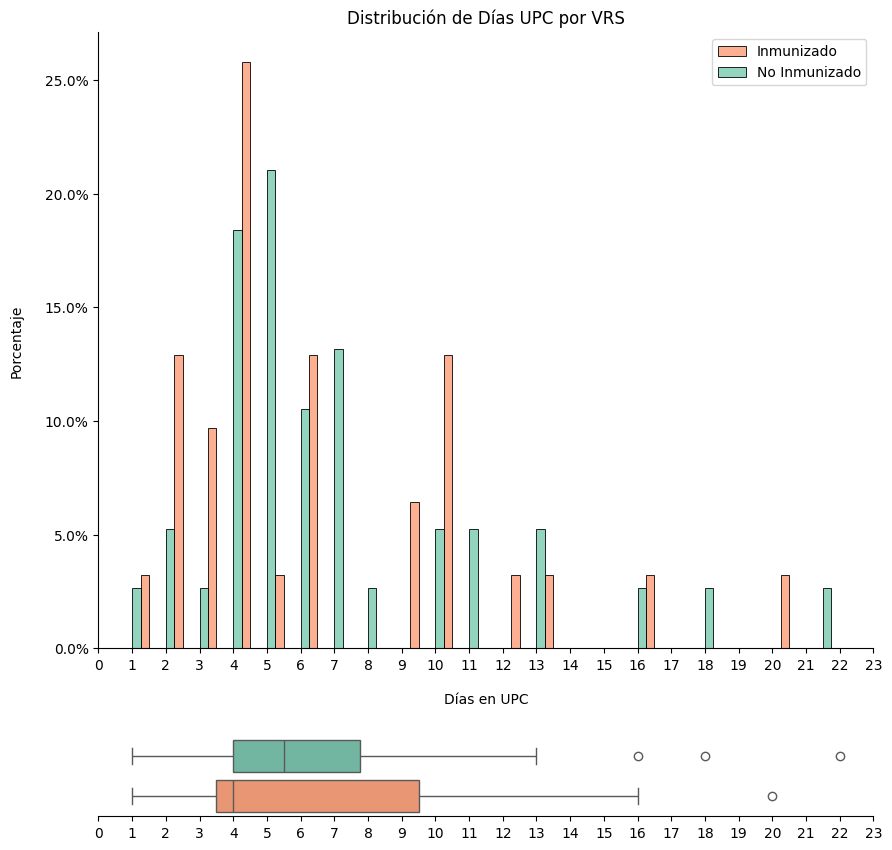

In [7]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

# Graficar el histograma en ax1
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días UPC por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_upc_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

### kde 

22.0


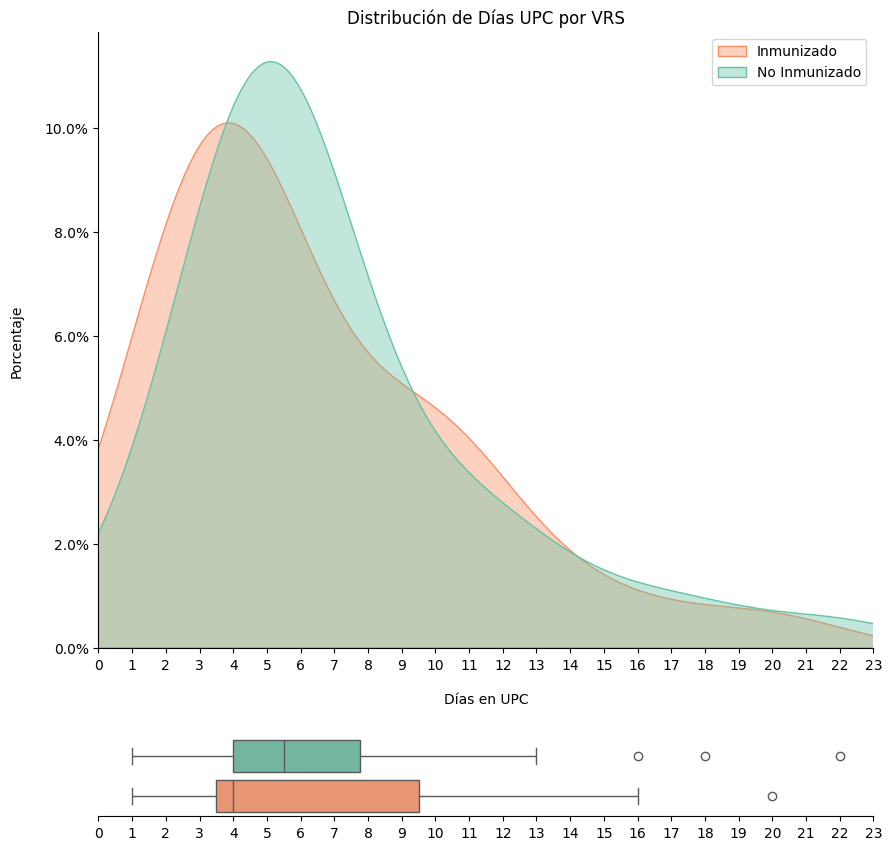

In [8]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días UPC por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_upc_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

## Días hospitalización

### histograma

26.0


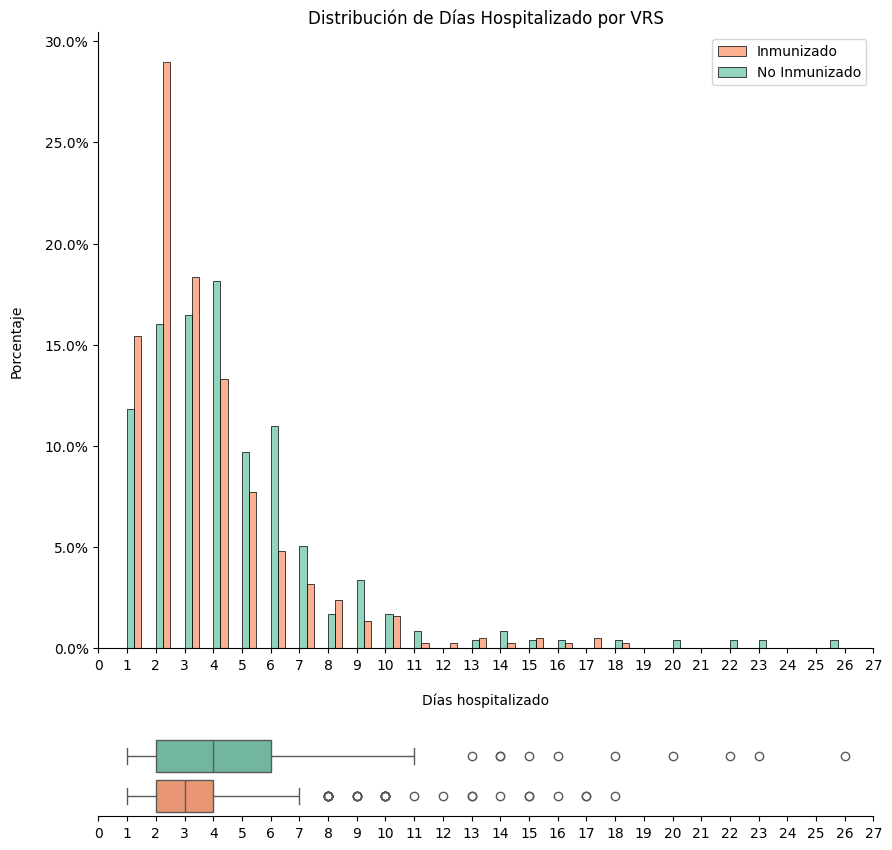

In [9]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

### kde

26.0


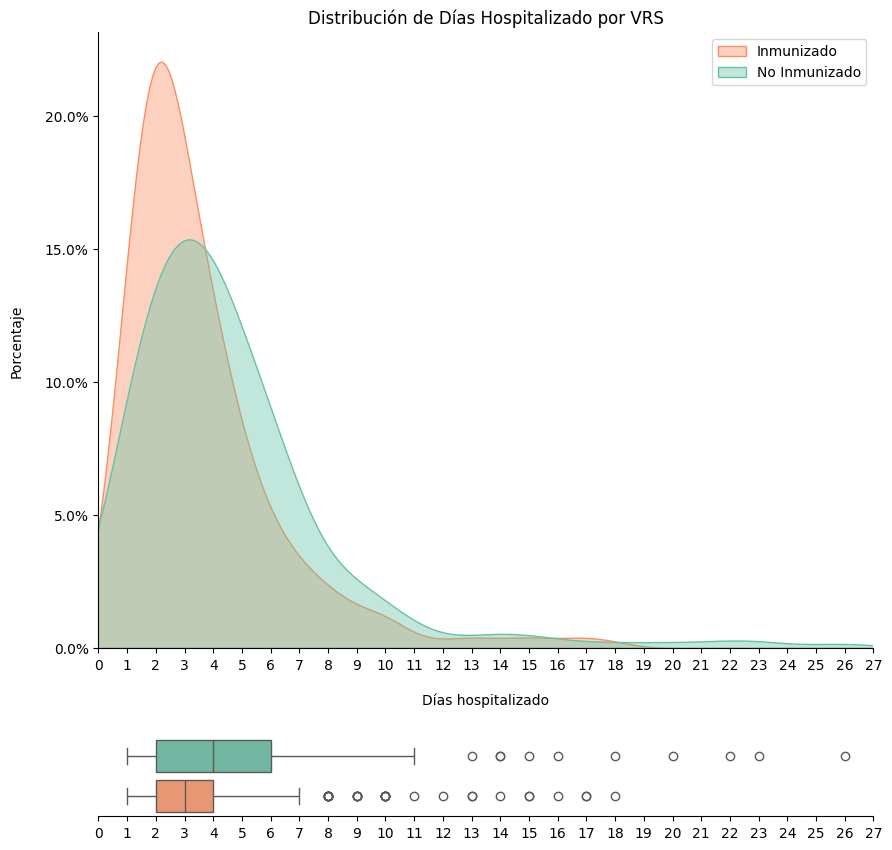

In [38]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

In [10]:
df = df[df['days_estad_vrs'] > 0]
df_prop = df.groupby(['inmunizado', 'days_estad_vrs'], as_index=False).size()

In [11]:
df_prop

,inmunizado,days_estad_vrs,size
0,0,1.0,28
1,0,2.0,38
2,0,3.0,39
3,0,4.0,43
4,0,5.0,23
5,0,6.0,26
6,0,7.0,12
7,0,8.0,4
8,0,9.0,8
9,0,10.0,4


In [12]:
n_inmunizado = df_prop[df_prop['inmunizado'] == 1]['size'].sum()
n_no_inmunizado = df_prop[df_prop['inmunizado'] == 0]['size'].sum()
df_prop['prop'] = np.where(df_prop['inmunizado'], df_prop['size'] / n_inmunizado, df_prop['size'] / n_no_inmunizado)
df_prop

,inmunizado,days_estad_vrs,size,prop
0,0,1.0,28,0.118143
1,0,2.0,38,0.160338
2,0,3.0,39,0.164557
3,0,4.0,43,0.181435
4,0,5.0,23,0.097046
5,0,6.0,26,0.109705
6,0,7.0,12,0.050633
7,0,8.0,4,0.016878
8,0,9.0,8,0.033755
9,0,10.0,4,0.016878


In [13]:
full_range = pd.MultiIndex.from_product([[0, 1], range(1, int(df_prop['days_estad_vrs'].max() + 1))], names=['inmunizado', 'days_estad_vrs'])
df_full = df_prop.set_index(['inmunizado', 'days_estad_vrs']).reindex(full_range, fill_value=0).reset_index()

In [15]:
days_vrs = df_full['prop'].tolist()
inmunizado = df_full['inmunizado'].tolist()

boxplot_data = df.groupby('inmunizado')['days_estad_vrs'].describe(percentiles=[.25, .5, .75])

In [16]:
boxplot_data

,count,mean,std,min,25%,50%,75%,max
inmunizado,,,,,,,,
0,237.0,4.620253,3.716559,1.0,2.0,4.0,6.0,26.0
1,376.0,3.611702,2.809179,1.0,2.0,3.0,4.0,18.0
